# Project 2

## Importing the data
We continue with the same research question from Project 1.

In [1]:
import pandas as pd

url = "https://docs.google.com/spreadsheets/d/1mJ3MtFkxHFdTEki1HjrdkAfIvekmWvltFn5S1KRnna8/export?format=csv"
df = pd.read_csv(url)
df.head()

,accident_id,severity_of_traffic,traffic_disruption_duration,distance_of_traffic,is_day,is_traffic_signal
0,194408,2,0.493611,0.01,1,1
1,194422,3,0.494167,1.13,1,0
2,194475,2,0.491389,0.01,1,0
3,194540,2,0.497500,0.01,0,1
4,194558,2,0.492222,0.01,1,1



## Research Question:

Is the traffic disruption duration different between accidents that occur with a nearby traffic signal and those without?

- `traffic_disruption_duration` is a continuous variable representing the length of time traffic was disrupted in hours.
- `is_traffic_signal` is a binary variable indicating whether there is a traffic signal near the location (`1` = yes, `0` = no).


## Question 1: Estimation


### Section (a)
We calculate the sample mean $\bar{X}$ of `traffic_disruption_duration` for each category of the binary variable `is_traffic_signal`.

In [2]:
# Calculate the average disruption duration per traffic signal group
df.groupby('is_traffic_signal')['traffic_disruption_duration'].agg(['mean', 'var', 'size'])

,mean,var,size
is_traffic_signal,,,
0,3.588511,3273.882585,14764
1,4.423578,7458.661763,4119


The average traffic disruption duration without a traffic signal (`is_traffic_signal = 0`) is `3.588511` hours,
while with a traffic signal (`is_traffic_signal = 1`) the average is `4.782634` hours.

We do note the very large variance in both groups, that affects mean, CI and hypothesis testing. We will analyze the data "as is", without removing outliers, as they are part of the real-world data. But a more sensitive analysis should be considered under different assumptions. (Removeing outliers or using median instead of mean, etc.) To visualize the variance, we plot boxplots of the two groups below.

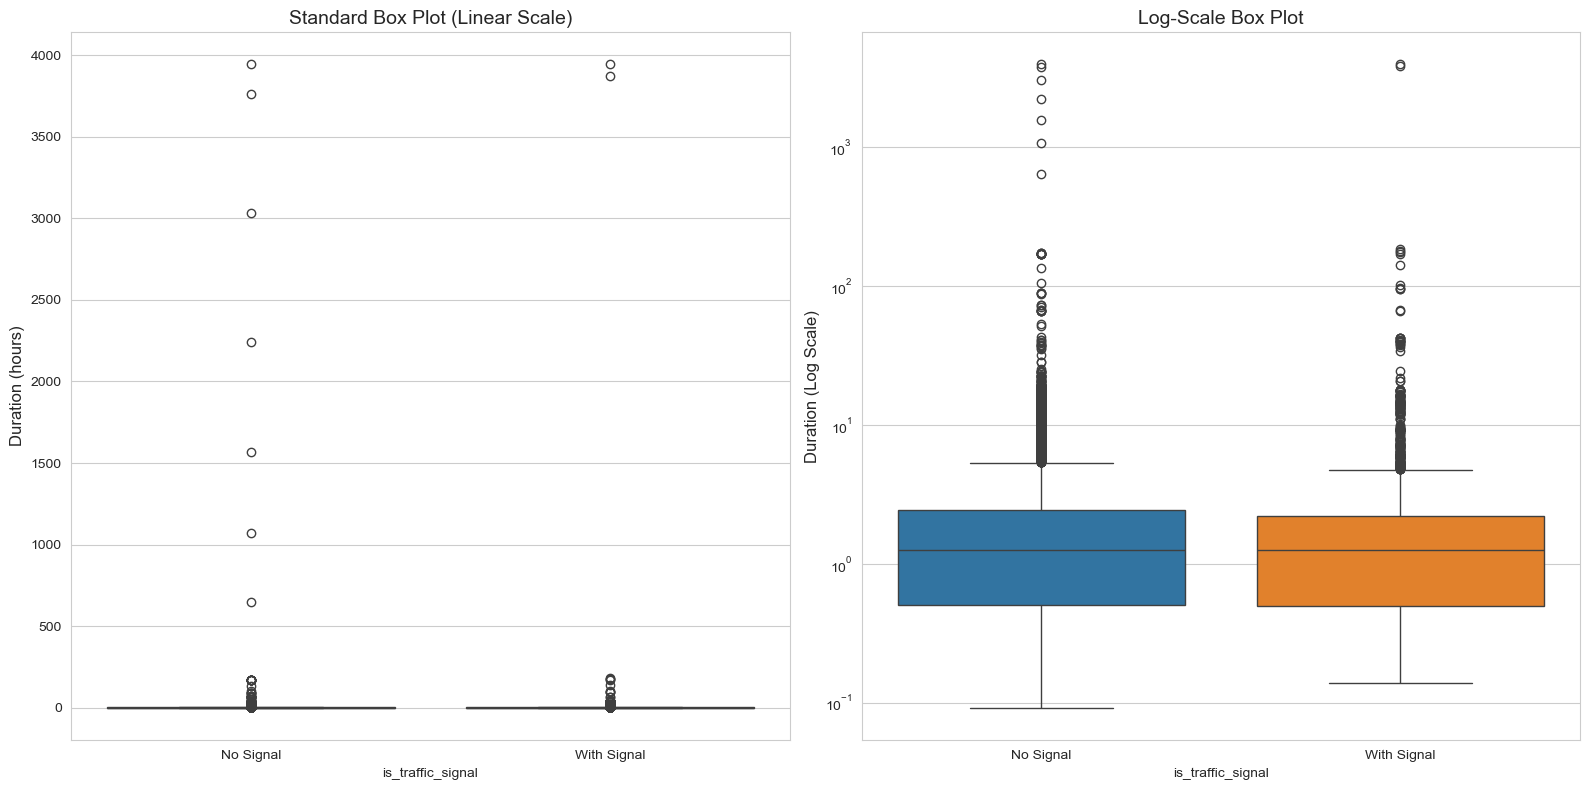

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# style
sns.set_style("whitegrid")
safe_palette = {0: '#1f77b4', 1: '#ff7f0e'}

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.boxplot(
    data=df, 
    x='is_traffic_signal', 
    y='traffic_disruption_duration',
    hue='is_traffic_signal',
    legend=False,
    palette=safe_palette, 
    ax=axes[0]
)
axes[0].set_title("Standard Box Plot (Linear Scale)", fontsize=14)
axes[0].set_ylabel("Duration (hours)", fontsize=12)

axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["No Signal", "With Signal"])

# log Scale
sns.boxplot(
    data=df, 
    x='is_traffic_signal', 
    y='traffic_disruption_duration',
    hue='is_traffic_signal',
    legend=False,
    palette=safe_palette, 
    ax=axes[1]
)
axes[1].set_yscale("log")
axes[1].set_title("Log-Scale Box Plot", fontsize=14)
axes[1].set_ylabel("Duration (Log Scale)", fontsize=12)

# Fix tick labels
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["No Signal", "With Signal"])

plt.tight_layout()
plt.show()

### Section (b)

We calculate an approximate 95% confidence interval for the expected value of `traffic_disruption_duration` in each category of `is_traffic_signal`.

We use the following formula for the confidence interval:

$$
\bar{X} \pm z_{\alpha/2} \cdot \sqrt{\frac{\hat{\sigma}^2}{n}}
$$

Where:

- $\bar{X}$ is the sample mean  
- $\hat{\sigma}^2$ is the sample variance $\hat{\sigma}^2=\frac{\sum(x_i-\bar{X})^2}{n-1}$
- $n$ is the sample size in the group  
- $z_{\alpha/2}$ is the z‑score for 95% confidence (approximately 1.96)

The variance $\hat{\sigma}^2$ and sample size $n$ are calculated separately for each group of `is_traffic_signal`, so each group has its own confidence interval.

Assuming:

$$
\bar{X} \sim N\left(\mu_X, \frac{\hat{\sigma}^2}{n}\right)
$$

This assumption comes from the Central Limit Theorem (CLT), which states that when the sample size is sufficiently large, the sampling distribution of the sample mean becomes approximately normal, regardless of the distribution of the original data. Since each group contains a large number of observations (4k, 14k), the normal approximation for the mean is appropriate.


In [4]:
import numpy as np
from scipy.stats import norm

# Z-score for 95% confidence
z = norm.ppf(0.975)

# Group stats, var by defulat is sample variance, divide by n-1
group_stats = df.groupby('is_traffic_signal')['traffic_disruption_duration'].agg(['mean', 'var', 'count'])
group_stats['SE'] = np.sqrt(group_stats['var'] / group_stats['count'])
group_stats['CI_lower'] = group_stats['mean'] - z * group_stats['SE']
group_stats['CI_upper'] = group_stats['mean'] + z * group_stats['SE']

# Print results as bullet points
for group, row in group_stats.iterrows():
    mean = row['mean']
    lower = row['CI_lower']
    upper = row['CI_upper']
    print(f"- Group is_traffic_signal = {group}:")
    print(f"  Mean disruption duration = {mean:.2f}")
    print(f"  95% Confidence Interval = [{lower:.2f}, {upper:.2f}]\n")

- Group is_traffic_signal = 0:
  Mean disruption duration = 3.59
  95% Confidence Interval = [2.67, 4.51]

- Group is_traffic_signal = 1:
  Mean disruption duration = 4.42
  95% Confidence Interval = [1.79, 7.06]



### Section (c)

The intervals above overlap, the first interval is a subset of the second interval.

The overlap between the confidence intervals suggests that the difference in mean `traffic_disruption_duration` between the two groups may not be statistically significant at the 95% confidence level. In other words, we do not have strong evidence to conclude that the average disruption time is different between accidents with and without a nearby traffic signal. A formal hypothesis test is needed to confirm this.

## Question 2: Hypothesis Testing

### Section (a)
We denote $\delta = \mu_1 - \mu_0$ as the difference in mean traffic disruption duration between accidents with and without a nearby traffic signal, donted as $\mu_1$ and $\mu_0$ respectively.

We set up the null and alternative hypotheses as follows:
- Null Hypothesis ($H_0$): There is no difference in the mean traffic disruption duration between accidents with and without a nearby traffic signal. Mathematically, this can be expressed as:
  
  $$
  H_0: \delta = 0 \quad \text{or} \quad \mu_0 = \mu_1
  $$
  
- Alternative Hypothesis ($H_1$): There is a difference in the mean traffic disruption duration between accidents with and without a nearby traffic signal. This can be expressed as:
    $$
    H_1: \delta \neq 0 \quad \text{or} \quad \mu_0 \neq \mu_1
    $$

### Section (b)
To check the assumptions for performing a t-test, we consider the following:

* Independence: The observations in each group (with and without traffic signals) should be independent of each other. This assumption is generally satisfied if the data collection process ensured that the accidents were independent events.
* Normality: We will eyeball the distribution of `traffic_disruption_duration` in each group to assess normality as a means of qualitative assessment.
* Equal Variances: We will use the F-test to compare the variances of the two groups.

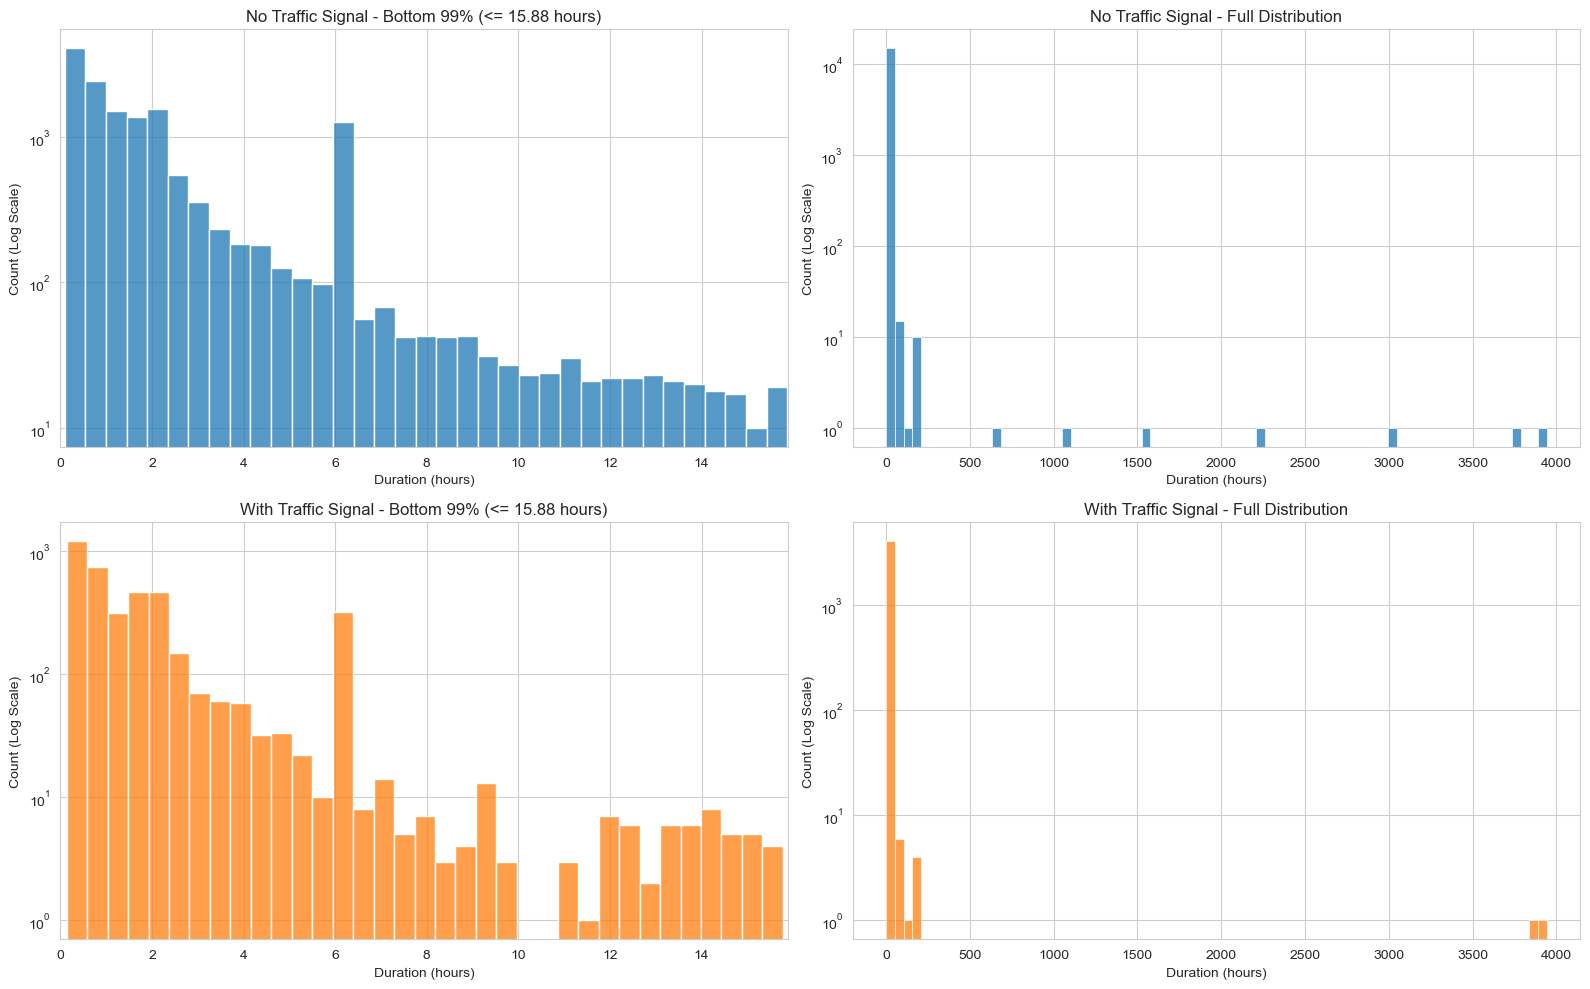

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 99th percentile so both groups use the same scale for the "clipped" view
col = 'traffic_disruption_duration'
global_p99 = np.percentile(df[col].dropna(), 99)

fig, axs = plt.subplots(2, 2, figsize=(16, 10))
groups = [
    {'label': 'No Traffic Signal', 'val': 0, 'color': '#1F77B4', 'row': 0}, # Blue
    {'label': 'With Traffic Signal', 'val': 1, 'color': '#FF7F0E', 'row': 1}  # Orange
]

for g in groups:
    # filter data for the group
    data = df[df['is_traffic_signal'] == g['val']][col].dropna()
    row = g['row']
    
    # plot only data <= global_p99
    sns.histplot(data[data <= global_p99], bins=35, color=g['color'], ax=axs[row, 0])
    axs[row, 0].set_title(f"{g['label']} - Bottom 99% (<= {global_p99:.2f} hours)")
    axs[row, 0].set_xlabel('Duration (hours)')
    axs[row, 0].set_ylabel('Count (Log Scale)')
    axs[row, 0].set_xlim(0, global_p99)
    axs[row, 0].set_yscale('log')

    # full dist.
    sns.histplot(data, bins=75, color=g['color'], ax=axs[row, 1])
    axs[row, 1].set_title(f"{g['label']} - Full Distribution")
    axs[row, 1].set_xlabel('Duration (hours)')
    axs[row, 1].set_ylabel('Count (Log Scale)')
    axs[row, 1].set_yscale('log')

plt.tight_layout()
plt.show()

As stated in ProjectEx1, `traffic_disruption_duration` shows extremely right-skewed distribution with a large concentration of very small values and a small number of extreme outliers.
Eyeballing the distributions suggests that the normality assumption is not reasonably met in bouth groups, we alose note the hard cutoff at 0 since time can not be negative.


F-Test
$$\begin{aligned}
& H_0: \sigma_0^2=\sigma_1^2 \\
& H_1: \sigma_0^2 \neq \sigma_1^2 \\
& \text { T.S.:F }=\frac{S_0^2}{S_1^2}=\frac{\frac{1}{n-1} \sum_{i=1}^n\left(X_{0,i}-\bar{X}_0\right)^2}{\frac{1}{m-1} \sum_{i=1}^n\left(X_{1,i}-\bar{X}_1\right)^2} \sim F_{(n-1, m-1)} \\
& \text { R.R.:F }>F_{(n-1, m-1), 1-\alpha}
\end{aligned}$$

In [6]:
from scipy.stats import f

# F-Test
F_stat = group_stats.loc[0, 'var'] / group_stats.loc[1, 'var']

#Rejection region
alpha = 0.05
F_critic = f.ppf(1 - alpha, group_stats.loc[0, 'count'] - 1, group_stats.loc[1, 'count'] - 1)

print(f"F-statistic: {F_stat:.4f}")
print(f"Critical F-value at alpha={alpha}: {F_critic:.4f}")
if F_stat > F_critic:
    print("Reject the null hypothesis: Variances are significantly different.") 
else:
    print("Fail to reject the null hypothesis: No significant difference in variances.")

F-statistic: 0.4389
Critical F-value at alpha=0.05: 1.0421
Fail to reject the null hypothesis: No significant difference in variances.


Summary: 
- Independence: Assumed satisfied based on data collection process.
- Normality: Eyeballing the distributions suggests that the normality assumption is not met.
- Equal Variances: The F-test results indicate that we fail to reject the null hypothesis of equal variances, suggesting that the variances in both groups are similar in a confidence level of 95%.

### Section (c)
We perform t-test to compare the means of `traffic_disruption_duration` between accidents with and without a nearby traffic signal.
We use the test statistic for difference in expectation when variances are assumed equal but unknown:

$$\begin{aligned}
T.S.:T & =\frac{\left(\bar{X}_0-\bar{X}_1\right)}{S_p \sqrt{\frac{1}{n_0}+\frac{1}{n_1}}} \\
S_p^2 & =\frac{\left(n_0-1\right) S_0^2+\left(n_1-1\right) S_1^2}{n_0+n_1-2}
\end{aligned}$$

In [7]:
from scipy.stats import t

# Calculate pooled standard deviation
n0 = group_stats.loc[0, 'count']
n1 = group_stats.loc[1, 'count']
var_0 = group_stats.loc[0, 'var']
var_1 = group_stats.loc[1, 'var']
s_p_sq = ((n0 - 1) * var_0 + (n1 - 1) * var_1) / (n0 + n1 - 2)
s_p = np.sqrt(s_p_sq)
# Calculate t-statistic
mean0 = group_stats.loc[0, 'mean']
mean1 = group_stats.loc[1, 'mean']
t_stat = (mean0 - mean1) / (s_p * np.sqrt(1/n0 + 1/n1))
# Degrees of freedom
dfree = n0 + n1 - 2
# Critical t-value for two-tailed test at alpha=0.05
t_critical = t.ppf(0.975, dfree)
p_val_t = (1 - t.cdf(abs(t_stat), dfree)) * 2
print(f"T-statistic: {t_stat:.4f}")
print(f"Critical t-value at alpha=0.05: ±{t_critical:.4f}")
if abs(t_stat) > t_critical:
    print("Reject the null hypothesis: There is a significant difference in mean disruption durations.")    
else:
    print("Fail to reject the null hypothesis: No significant difference in mean disruption durations.")

print(f"T-test p-value: {p_val_t:.4f}")

T-statistic: -0.7324
Critical t-value at alpha=0.05: ±1.9601
Fail to reject the null hypothesis: No significant difference in mean disruption durations.
T-test p-value: 0.4639


### Section (d)
We test the hypothesis using a wald test
$$ W=\frac{\left(\hat{\mu}_0-\hat{\mu}_1\right)}{\sqrt{\frac{\hat{\sigma}_0^2}{n_0}+\frac{\hat{\sigma}_1^2}{n_1}}} $$
$$ R.R.:|W|>z_{1 - \tilde{\alpha}/2} $$

In [8]:
W_stat = (mean0 - mean1) / np.sqrt((var_0 / n0) + (var_1 / n1))
W_critical = norm.ppf(1 - 0.05 / 2)
p_val_W = (1 - norm.cdf(abs(W_stat))) * 2
print(f"Wald Statistic: {W_stat:.4f}")
print(f"Critical Z-value at alpha=0.05: ±{W_critical:.4f}")
if abs(W_stat) > W_critical:
    print("Reject the null hypothesis: There is a significant difference in mean disruption durations.")
else:
    print("Fail to reject the null hypothesis: No significant difference in mean disruption durations.")

print(f"Wald test p-value: {p_val_W:.4f}")

Wald Statistic: -0.5857
Critical Z-value at alpha=0.05: ±1.9600
Fail to reject the null hypothesis: No significant difference in mean disruption durations.
Wald test p-value: 0.5581


### Section (e)
We compare the results and their p-values from both the t-test and the Wald test.
Both tests fail to reject the null hypothesis (t-test p-value: 0.4639, wald test p-value:0.5581). This means, that even if traffic signals had no effect on the duration of traffic distruptions, we would see our calculated difference by chance around 50% of the time. This suggests that the observed difference is not statistically significant and is indistinguishable from random noise. Consequently, the data provides no evidence to support the claim that the presence of traffic signals influences the duration of traffic disruptions.

## Section (f)
We perform a likelihood ratio test to check the difference in means between the two groups.

We use the folloing likelihood functions:

$$\mathcal{L}(\hat{\mu}_1, \hat{\mu}_2) = \frac{1}{\left(\sqrt{2\pi S_p^2}\right)^n} \prod_{i=1}^{n_1} e^{-(x_{1i}-\hat{\mu}_1)^2/2S_p^2} \prod_{j=1}^{n_2} e^{-(x_{2j}-\hat{\mu}_2)^2/2S_p^2}$$
$$\mathcal{L}(\hat{\mu}) = \frac{1}{\left(\sqrt{2\pi \hat{\sigma}^2}\right)^n} \prod_{i=1}^{n} e^{-(x_{i}-\hat{\mu})^2/2\hat{\sigma}^2}$$

Take the log:

$$\ell(\hat{\mu}_1, \hat{\mu}_2) = -\frac{n}{2} \ln(2\pi) - \frac{n}{2} \ln(S_p^2) - \frac{1}{2 S_p^2} \left[ \sum_{i=1}^{n_1} (x_{1i} - \hat{\mu}_1)^2 + \sum_{j=1}^{n_2} (x_{2j} - \hat{\mu}_2)^2 \right]$$
$$\ell(\hat{\mu}) = -\frac{n}{2} \ln(2\pi) - \frac{n}{2} \ln(\hat{\sigma}^2) - \frac{1}{2 \hat{\sigma}^2} \sum_{i=1}^{n} (x_i - \hat{\mu})^2$$

$$ H_0: \mu_0 - \mu_1 = 0 $$
$$ H_1: \mu_0 - \mu_1 \neq 0 $$

$$ T.S.: \lambda = -2 \ln \left( \frac{\mathcal{L}(\hat{\mu})}{\mathcal{L}(\hat{\mu}_1, \hat{\mu}_2)} \right) $$

$$ R.R.: \lambda > \chi^2_{1, 1-\alpha} $$

In [9]:
from scipy.stats import chi2
n1 = group_stats.loc[1, 'count']
n0 = group_stats.loc[0, 'count']
n = n0 + n1
data0 = df[df['is_traffic_signal'] == 0]['traffic_disruption_duration']
data1 = df[df['is_traffic_signal'] == 1]['traffic_disruption_duration']
total_mean = df['traffic_disruption_duration'].mean()
total_var = df['traffic_disruption_duration'].var()

sse_sep = np.sum((data0 - mean0)**2) + np.sum((data1 - mean1)**2)
sse_total = np.sum((df['traffic_disruption_duration'] - total_mean)**2)

log_likelihood_H1 = -n/2 * np.log(2*np.pi) -n/2 * np.log(s_p_sq) - 1/(2*s_p_sq) * (sse_sep)
log_likelihood_H0 = -n/2 * np.log(2*np.pi) -n/2 * np.log(total_var) - 1/(2*total_var) * (sse_total)
lambda_stat = -2 * (log_likelihood_H0 - log_likelihood_H1)

chi_critical = chi2.ppf(0.95, df=1) 
print(f"Likelihood Ratio Statistic: {lambda_stat:.4f}")
print(f"Critical Chi-square value at alpha=0.05: {chi_critical:.4f}")
if lambda_stat > chi_critical:
    print("Reject the null hypothesis: There is a significant difference in mean disruption durations.")
else:
    print("Fail to reject the null hypothesis: No significant difference in mean disruption durations.")

Likelihood Ratio Statistic: 0.5364
Critical Chi-square value at alpha=0.05: 3.8415
Fail to reject the null hypothesis: No significant difference in mean disruption durations.


## Question 3: Different sample sizes

### Section (a)
We sample 4 times (30,50,100,500)

In [10]:
# Sample
import numpy as np
sample_sizes = [30, 50, 100, 500]
results = {}
for size in sample_sizes:
    sample = df.sample(n=size, random_state=42)
    group_stats_sample = sample.groupby('is_traffic_signal')['traffic_disruption_duration'].agg(['mean', 'var', 'count'])
    print(f"Size: [{size}] group_stats_sample:\n{group_stats_sample}\n")
    results[size] = (sample, group_stats_sample)

Size: [30] group_stats_sample:
                       mean       var  count
is_traffic_signal                           
0                  1.543857  2.335493     26
1                  1.382292  0.445430      4

Size: [50] group_stats_sample:
                       mean        var  count
is_traffic_signal                            
0                  2.224562  15.405067     40
1                  1.860528   3.272592     10

Size: [100] group_stats_sample:
                       mean        var  count
is_traffic_signal                            
0                  2.087372   9.757332     78
1                  2.364545  12.823811     22

Size: [500] group_stats_sample:
                       mean        var  count
is_traffic_signal                            
0                  2.461721  12.400124    392
1                  2.122070   8.033372    108



### Section (b)
We find confidence intervals for each sample size and group.

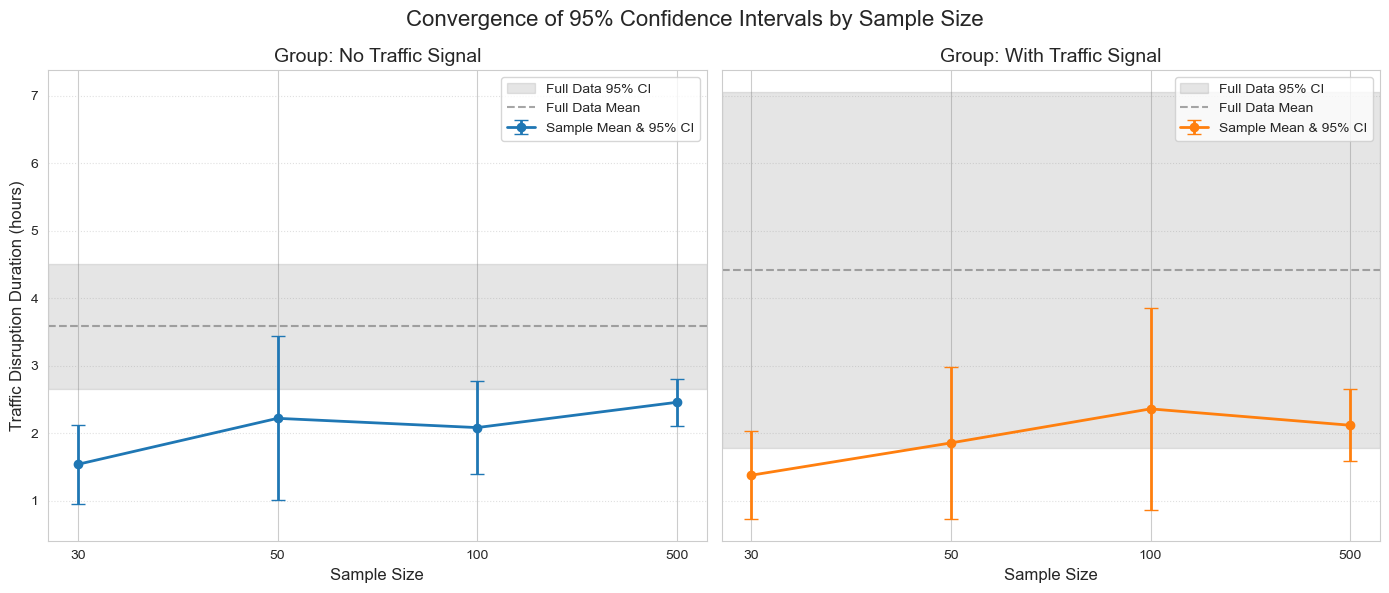

In [11]:
# CI for each sample size and group
CIs = {}
z = norm.ppf(0.975)
for size, (sample, stats) in results.items(): 
    ci_dict = {}
    for group in [0, 1]:
        if group in stats.index:
            mean = stats.loc[group, 'mean']
            var = stats.loc[group, 'var']
            count = stats.loc[group, 'count']
            
            se = np.sqrt(var / count)
            ci_lower = mean - z * se
            ci_upper = mean + z * se
            
            ci_dict[group] = (ci_lower, ci_upper, mean)
            
    CIs[size] = ci_dict

# Visualize CIs and compare to full data CI (group_stats['CI_lower'], group_stats['CI_upper'])
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
group_labels = {0: 'No Traffic Signal', 1: 'With Traffic Signal'}
colors = {0: '#1f77b4', 1: '#ff7f0e'} # Blue / Orange

for idx, group in enumerate([0, 1]):
    ax = axs[idx]
    
    # A. Extract data for this group across sample sizes
    sizes = sorted(CIs.keys())
    means = []
    yerrs = [] # Error bar lengths (distance from mean to CI bound)
    
    for s in sizes:
        if group in CIs[s]:
            low, high, mu = CIs[s][group]
            means.append(mu)
            # Error is symmetric here, so we just take (high - low) / 2
            yerrs.append((high - low) / 2)
        else:
            means.append(np.nan)
            yerrs.append(np.nan)

    # B. Plot the Full Data Reference (The "Truth")
    # We use a shaded span to represent the CI of the full dataset
    full_low = group_stats.loc[group, 'CI_lower']
    full_high = group_stats.loc[group, 'CI_upper']
    full_mean = group_stats.loc[group, 'mean']
    
    ax.axhspan(full_low, full_high, color='gray', alpha=0.2, label='Full Data 95% CI')
    ax.axhline(full_mean, color='gray', linestyle='--', alpha=0.7, label='Full Data Mean')

    # C. Plot the Sample CIs with Error Bars
    ax.errorbar(
        [str(s) for s in sizes], # X-axis labels
        means, 
        yerr=yerrs, 
        fmt='o-', 
        capsize=5, 
        color=colors[group],
        linewidth=2,
        label='Sample Mean & 95% CI'
    )
    
    # Styling
    ax.set_title(f"Group: {group_labels[group]}", fontsize=14)
    ax.set_xlabel("Sample Size", fontsize=12)
    ax.grid(axis='y', linestyle=':', alpha=0.6)
    
    if idx == 0:
        ax.set_ylabel("Traffic Disruption Duration (hours)", fontsize=12)
        ax.legend(loc='upper right')
    else:
        ax.legend(loc='upper right')

plt.suptitle("Convergence of 95% Confidence Intervals by Sample Size", fontsize=16)
plt.tight_layout()
plt.show()

According to the CLT, we expect that as the sample size increases, the sample means (colored dots) should converge to the full population mean (gray dashed line) and the confidence intervals should narrow symmetrically around that. The results largely follows this expectation: the means hover near the true average, and the intervals tighten as expected (except from 30-50 and 50-100 which are very small and have a high variance as shown above). But  the sample means consistently underestimate the true population mean (falling below the gray line), and the confidence intervals often fail to capture the true mean entirely.

One possible reason is the skew (heavy tails), a small numbers of outliers that are not present in the samples heavily affacet the full data mean, as examplified in the histograms above and in the table below:

In [12]:
import pandas as pd

true_means = df.groupby('is_traffic_signal')['traffic_disruption_duration'].mean()

datasets = [('Full Data', df)] + [
    (f'Sample (n={size})', results[size][0] if isinstance(results[size], tuple) else results[size]) 
    for size in sorted(results.keys())
]

table_data = []
for label, data in datasets:
    stats = data.groupby('is_traffic_signal')['traffic_disruption_duration'].agg(['max', 'mean'])
    
    for group in [0, 1]:
        table_data.append({
            'Dataset': label,
            'Group': group,
            'Max Value': stats.loc[group, 'max'],
            'Sample Mean': stats.loc[group, 'mean']
        })

# 4. Display
summary_df = pd.DataFrame(table_data)
pd.options.display.float_format = '{:.2f}'.format
display(summary_df)

,Dataset,Group,Max Value,Sample Mean
0,Full Data,0,3943.23,3.59
1,Full Data,1,3943.23,4.42
2,Sample (n=30),0,6.00,1.54
3,Sample (n=30),1,2.25,1.38
4,Sample (n=50),0,24.29,2.22
5,Sample (n=50),1,6.00,1.86
6,Sample (n=100),0,24.29,2.09
7,Sample (n=100),1,16.00,2.36
8,Sample (n=500),0,37.92,2.46
9,Sample (n=500),1,16.22,2.12


### Section (c)
We perform wald tests for each sample size to compare the means of `traffic_disruption_duration` between accidents with and without a nearby traffic signal and compare the results to those obtained in Question 2.

In [13]:
import pandas as pd
import numpy as np
from scipy.stats import norm

# List to hold all rows
table_rows = []

# full data results from your previous run
table_rows.append({
    'Dataset': 'Full Data',
    'Sample Size': n0 + n1, # Using the full N
    'Wald Statistic': W_stat,
    'Critical Value': W_critical,
    'P-value': p_val_W,
    'Reject Null?': 'Yes' if abs(W_stat) > W_critical else 'No'
})

# samples 
for size, (sample, stats) in results.items():
    # Only proceed if both groups exist in the sample
    n0_s = stats.loc[0, 'count']
    n1_s = stats.loc[1, 'count']
    mean0_s = stats.loc[0, 'mean']
    mean1_s = stats.loc[1, 'mean']
    var0_s = stats.loc[0, 'var']
    var1_s = stats.loc[1, 'var']
    
    # Calculate Wald Statistic for this sample
    W_stat_sample = (mean0_s - mean1_s) / np.sqrt((var0_s / n0_s) + (var1_s / n1_s))
    
    # Critical Value and P-value
    W_critical_sample = norm.ppf(1 - 0.05 / 2)
    p_val_sample = (1 - norm.cdf(abs(W_stat_sample))) * 2
    
    table_rows.append({
        'Dataset': 'Sample',
        'Sample Size': size,
        'Wald Statistic': W_stat_sample,
        'Critical Value': W_critical_sample,
        'P-value': p_val_sample,
        'Reject Null?': 'Yes' if abs(W_stat_sample) > W_critical_sample else 'No'
    })


# Formatting
wald_summary_df = pd.DataFrame(table_rows)
pd.options.display.float_format = '{:.4f}'.format
display(wald_summary_df)

,Dataset,Sample Size,Wald Statistic,Critical Value,P-value,Reject Null?
0,Full Data,18883,-0.5857,1.9600,0.5581,No
1,Sample,30,0.3602,1.9600,0.7187,No
2,Sample,50,0.4313,1.9600,0.6662,No
3,Sample,100,-0.3294,1.9600,0.7418,No
4,Sample,500,1.0432,1.9600,0.2969,No


The Wald test consistently fails to reject the null hypothesis across all sample sizes, matching the conclusion of the full dataset (p-value $\approx$ 0.55). With smaller sample sizes we might observe less variance, but with less outliers the sample means get closer to each other, making it hard to detect a difference. Overall, the results suggest that even with varying sample sizes, there is no significant difference in traffic disruption duration between accidents with and without nearby traffic signals.

### Section (d)
We repeat the sampling process (N=100), and plot CI lengths and p-values to describe their distribution as a function of sample size. 

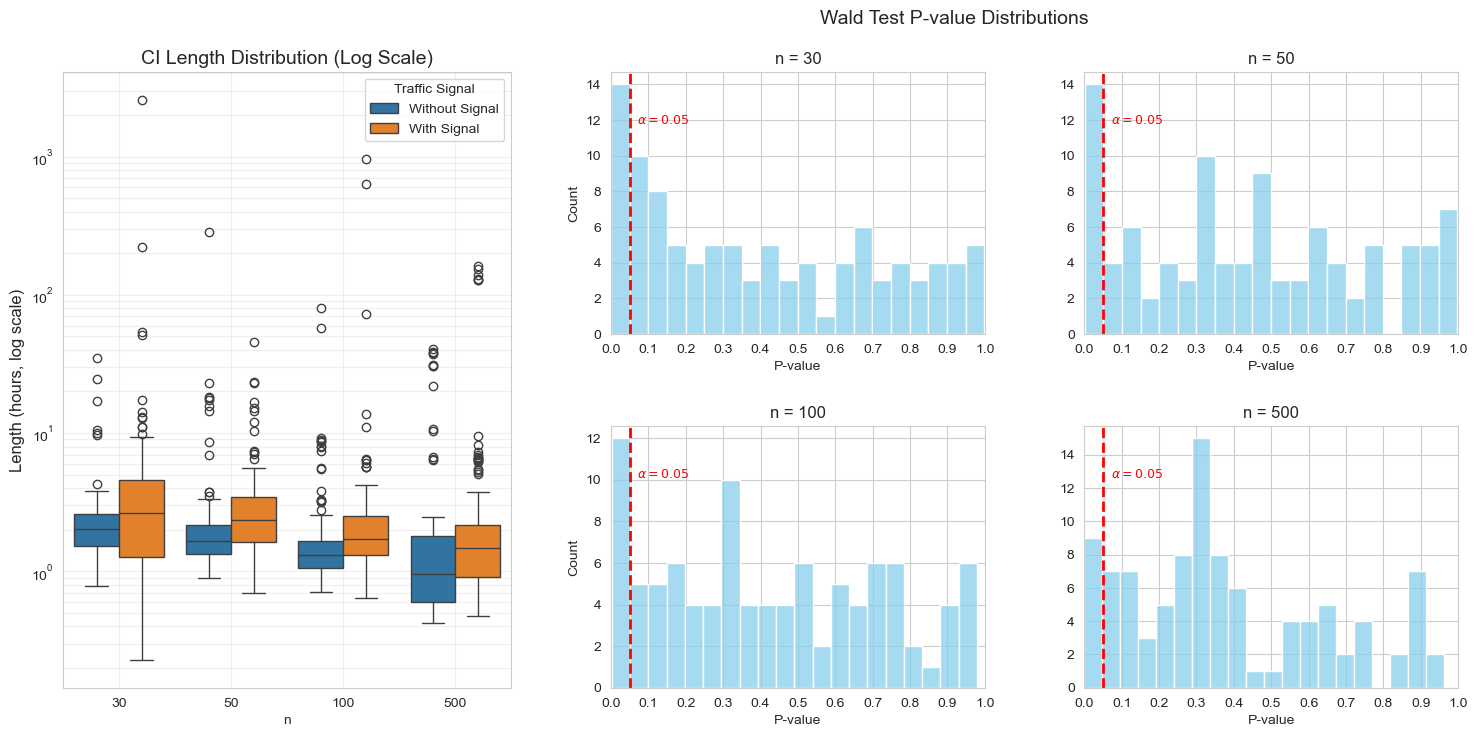

Coverage Percentage (How often is the True Mean inside the CI?):
            With Signal Without Signal
Sample Size                           
30                29.0%          36.0%
50                24.0%          31.0%
100               16.0%          24.0%
500               23.0%          32.0%


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import matplotlib.gridspec as gridspec

# reproducible results
np.random.seed(42)

# get true means from the full dataset for comparison later
full_means = df.groupby('is_traffic_signal')['traffic_disruption_duration'].mean()
z = norm.ppf(0.975) # 1.96 ish

data_ci = []
data_wald = []

# run 100 simulations
for i in range(100):
    for size in [30, 50, 100, 500]:
        sample = df.sample(n=size)
        stats = sample.groupby('is_traffic_signal')['traffic_disruption_duration'].agg(['mean', 'var', 'count'])
        
        # rarely a sample might miss a group entirely
        if len(stats) < 2: continue

        # 1. CI analysis
        for group in [0, 1]:
            mean, var, count = stats.loc[group]
            se = np.sqrt(var / count)
            ci_len = 2 * z * se
            
            # did this sample's interval catch the true mean?
            lower, upper = mean - z*se, mean + z*se
            is_covered = lower <= full_means[group] <= upper
            
            label = "Without Signal" if group == 0 else "With Signal"
            data_ci.append({'n': size, 'val': ci_len, 'group': label, 'covered': is_covered})

        # 2. wald test
        n0, n1 = stats.loc[0, 'count'], stats.loc[1, 'count']
        v0, v1 = stats.loc[0, 'var'], stats.loc[1, 'var']
        m0, m1 = stats.loc[0, 'mean'], stats.loc[1, 'mean']
        
        se_diff = np.sqrt(v0/n0 + v1/n1)
        wald = (m0 - m1) / se_diff
        pval = 2 * (1 - norm.cdf(abs(wald)))
        
        data_wald.append({'n': size, 'val': pval})

res_ci = pd.DataFrame(data_ci)
res_wald = pd.DataFrame(data_wald)

# set up a nice grid layout
fig = plt.figure(figsize=(18, 8))
gs = gridspec.GridSpec(2, 3, width_ratios=[1.2, 1, 1], wspace=0.25, hspace=0.35)

# left plot: CI lengths (log scale is a must here)
ax_ci = plt.subplot(gs[:, 0])
sns.boxplot(data=res_ci, x='n', y='val', hue='group', ax=ax_ci)
ax_ci.set_yscale('log')
ax_ci.set_title('CI Length Distribution (Log Scale)', fontsize=14)
ax_ci.set_ylabel('Length (hours, log scale)', fontsize=12)
ax_ci.legend(title='Traffic Signal')
# ADDED: gridlines for better log scale reading
ax_ci.grid(True, which="both", ls="-", alpha=0.3)

# right plots: 4-panel p-value histograms
sample_sizes = [30, 50, 100, 500]
positions = [(0, 1), (0, 2), (1, 1), (1, 2)]

fig.text(0.62, 0.94, 'Wald Test P-value Distributions', ha='center', fontsize=14)

for i, size in enumerate(sample_sizes):
    row, col = positions[i]
    ax = plt.subplot(gs[row, col])
    
    subset = res_wald[res_wald['n'] == size]
    # 20 bins for detail
    sns.histplot(data=subset, x='val', bins=20, color='skyblue', ax=ax, edgecolor='white')
    
    # mark alpha=0.05
    ax.axvline(0.05, color='r', ls='--', linewidth=2)
    ax.text(0.07, ax.get_ylim()[1]*0.8, r'$\alpha=0.05$', color='red', fontsize=9)
    
    # ADDED: specific x-ticks every 0.1
    ax.set_xticks(np.arange(0, 1.1, 0.1))
    
    ax.set_title(f'n = {size}')
    ax.set_xlim(0, 1.0)
    ax.set_xlabel('P-value')
    if col == 1: ax.set_ylabel('Count')
    else: ax.set_ylabel('')

plt.show()

# print final coverage stats
print("Coverage Percentage (How often is the True Mean inside the CI?):")
coverage = res_ci.groupby(['n', 'group'])['covered'].mean() * 100
coverage_df = coverage.unstack()
coverage_df.index.name = "Sample Size"
coverage_df.columns.name = None

print(coverage_df.map(lambda x: f"{x:.1f}%"))

1. CI Length Distribution (Log Scale): The CI legnths behaves as theoretically expected: confidence intervals are narrow (~2-5 hours) and tighten as sample size increases. The data demonstrates variability. the upper whiskers and outliers extend to $10^3$ hours. This massive spread confirms the presence of heavy-tailed data if the sample includes the outliers, the variance explodes, resulting in a wider than typical CI.

2. Wald Test P-value: The p-value histograms reveal a deviation from the uniform distribution we would expect if the Null Hypothesis were true and the test assumptions were met. We see a spike in low p-values (rejections) for the smaller sample sizes ($n=30, 50$), despite the full dataset failing to reject the null. This might be thanks to the heavy-tailed nature of the data. Small random samples frequently miss the rare, extreme outliers causing rejections. As the sample size increases and inevitably captures these outliers, the variance explodes, effectively correcting the test and aligning the results with the non-significant conclusion of the full dataset.

3. True mean in CI: coverage rates are around 20–35% instead of the theoretical 95%. This could be a result of neither group satisfying the normality assumptions required for CLT. Because both distributions are extremely skewed, random samples underestimate the true variance and the true mean (affected by outliers), causing them to miss the target ~70% of the time.